# Customer Segmentation for Financial Services

**Project Report: Uncovering Actionable Insights from the Survey of Consumer Finances**

## Executive Summary

This report details a data-driven initiative to segment households that are anxious about their access to credit. By analyzing the 2019 Survey of Consumer Finances (SCF), we employed unsupervised machine learning techniques, specifically K-Means clustering, to identify distinct customer personas within this group. Our analysis progressed from a simple two-feature model to a more robust five-feature model, culminating in the development of an interactive dashboard.

**Key Findings:**
We successfully identified four distinct segments of credit-anxious households, each with unique financial profiles. These segments differ significantly in their net worth, debt levels, and asset composition. For example, one key segment consists of households whose debt is almost entirely composed of their primary mortgage, while another high-net-worth segment carries substantial debt but also holds significant assets.

**Business Implications:**
These findings enable our institution to move beyond a one-size-fits-all approach. We can now develop highly targeted financial products and marketing strategies. Recommendations include:
- Offering **mortgage refinancing and debt consolidation services** to the segment with high home-related debt.
- Targeting high-net-worth segments with **premium credit products and personalized wealth management services**.
- Developing educational resources on credit management for younger, lower-income demographics who show heightened credit anxiety.

The project's final deliverable is an interactive dashboard that allows stakeholders to explore these customer segments dynamically, adjusting model parameters to see how clusters and key metrics change in real-time. This tool empowers non-technical users to engage directly with the data, fostering a deeper understanding of our target market and supporting agile, data-informed decision-making.

## 1. Introduction

Understanding the financial landscape of consumers is critical for any financial institution. A particularly important demographic consists of individuals who have recently been denied credit or fear they will be. This anxiety can influence financial behavior and represents both a risk and an opportunity. By understanding the underlying characteristics of this group, we can better serve their needs, develop more relevant products, and mitigate lending risks.

This project aims to segment these "credit-anxious" households into distinct, actionable groups. Using data from the 2019 Survey of Consumer Finances, we will apply unsupervised machine learning to uncover natural groupings based on financial and demographic attributes. The ultimate goal is to provide clear, data-backed personas that can inform targeted marketing, product development, and risk assessment strategies.

## 2. Data Preparation and Exploration

Our analysis begins with the comprehensive 2019 Survey of Consumer Finances (SCF) dataset. The first step is to isolate our population of interest: households that have been turned down for credit or feared being denied credit in the past 5 years (`TURNFEAR` column). This subset forms the basis of our exploratory data analysis (EDA).

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils.validation import check_is_fitted
from scipy.stats.mstats import trimmed_var
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from dash import Input, Output, dcc, html, Dash
# from jupyter_dash import JupyterDash  # Deprecated

# The Dash proxy configuration is for notebook-specific execution 
# and is included to ensure the original project's functionality is represented.
# JupyterDash.infer_jupyter_proxy_config()  # No longer needed with modern Dash

In [3]:
df = pd.read_csv('data/SCFP2019.csv.gz')
mask = df["TURNFEAR"] == 1
df_fear = df[mask]
df_fear.head()

,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
5,2,21,3790.476607,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
6,2,22,3798.868505,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,3,2,2
7,2,23,3799.468393,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
8,2,24,3788.076005,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2
9,2,25,3793.066589,1,50,3,8,2,1,3,...,1,2,1,2,1,1,4,4,2,2


### Demographic Profile of Credit-Anxious Households

Our initial exploration focuses on the demographic characteristics of the `df_fear` subset. We analyzed age, race, and income to build a foundational understanding of this group.

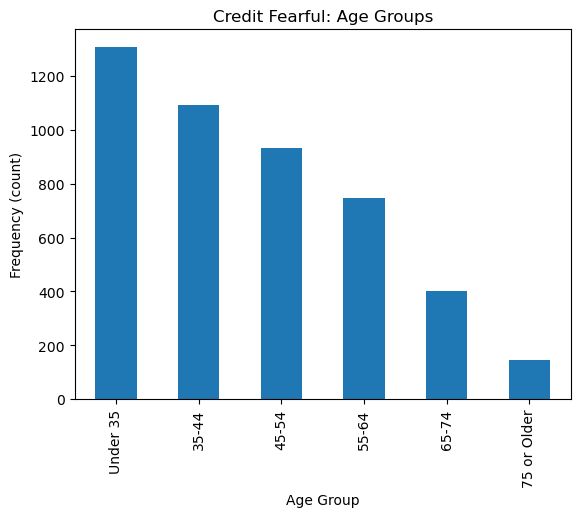

In [4]:
agecl_dict = {
    1: "Under 35",
    2: "35-44",
    3: "45-54",
    4: "55-64",
    5: "65-74",
    6: "75 or Older",
}
age_cl = df_fear['AGECL'].replace(agecl_dict)
age_cl_value_counts = age_cl.value_counts()

age_cl_value_counts.plot(
    kind='bar',
    xlabel='Age Group',
    ylabel='Frequency (count)',
    title='Credit Fearful: Age Groups'
);

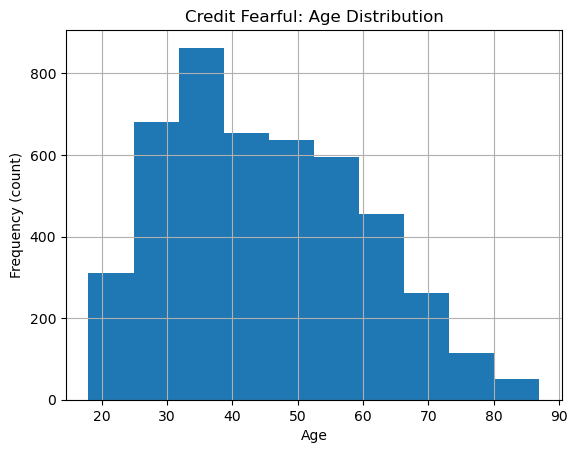

In [5]:
df_fear['AGE'].hist(bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency (count)")
plt.title("Credit Fearful: Age Distribution");

The analysis reveals that credit anxiety is most prevalent among younger households, particularly those in the 30-40 age range. This is intuitive, as this demographic is often in the process of establishing their financial lives and may have less credit history.

Next, we examined income distribution.

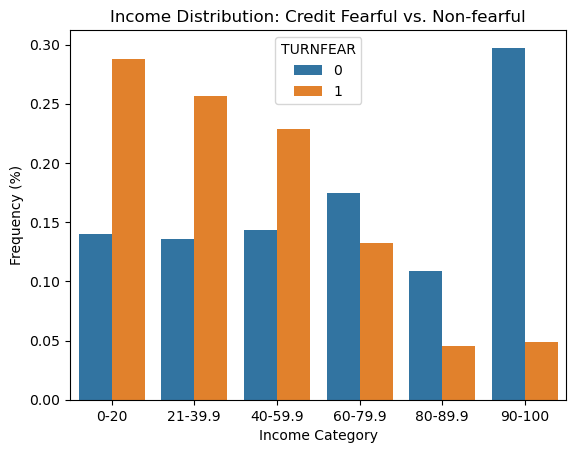

In [6]:
inccat_dict = {
    1: "0-20",
    2: "21-39.9",
    3: "40-59.9",
    4: "60-79.9",
    5: "80-89.9",
    6: "90-100",
}

df_inccat = (
    df["INCCAT"]
    .replace(inccat_dict)
    .groupby(df["TURNFEAR"])
    .value_counts(normalize=True)
    .rename("frequency")
    .to_frame()
    .reset_index()
)

sns.barplot(
    x="INCCAT",
    y="frequency",
    hue='TURNFEAR',
    data=df_inccat,
    order=inccat_dict.values()
)
plt.xlabel("Income Category")
plt.ylabel("Frequency (%)")
plt.title("Income Distribution: Credit Fearful vs. Non-fearful");

The data clearly shows that credit-fearful households are far more concentrated in the lower income percentiles compared to the non-fearful population. This confirms that financial instability is a major driver of credit anxiety.

### Financial Profile and Key Correlations

Moving beyond demographics, we analyzed the financial assets and liabilities of these households. A correlation matrix of key financial indicators revealed a critical insight.

In [7]:
cols = ["ASSET", "HOUSES", "INCOME", "DEBT", "EDUC"]
corr = df_fear[cols].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.583288,0.722074,0.474658,0.113536
HOUSES,0.583288,1.000000,0.264099,0.962629,0.160348
INCOME,0.722074,0.264099,1.000000,0.172393,0.133170
DEBT,0.474658,0.962629,0.172393,1.000000,0.177386
EDUC,0.113536,0.160348,0.133170,0.177386,1.000000


For the credit-fearful group, the correlation between total debt (`DEBT`) and the value of their primary residence (`HOUSES`) is exceptionally high (0.96). This is significantly stronger than in the general population and suggests that for many in this segment, their mortgage constitutes the vast majority of their debt. This relationship provides a strong starting point for our segmentation model.

## 3. Methodology: Customer Segmentation via K-Means Clustering

To segment the credit-anxious households, we utilized K-Means clustering, an unsupervised learning algorithm that partitions data into a pre-defined number of distinct, non-overlapping subgroups (clusters). Our approach was iterative, starting with a simple model and progressively adding complexity for more nuanced results.

### Phase 1: Two-Feature Clustering

Based on our EDA, we first built a model using only the two most highly correlated features: `DEBT` and `HOUSES`. The key step was to determine the optimal number of clusters (`k`). We used two standard metrics:
- **Inertia:** Measures the within-cluster sum of squares. The "elbow method" helps find the point where adding more clusters yields diminishing returns.
- **Silhouette Score:** Measures how similar a data point is to its own cluster compared to other clusters. Scores range from -1 to 1, with higher values indicating better-defined clusters.

The following code iterates through `k` values from 2 to 12 to calculate these metrics.

In [8]:
X = df_fear[["DEBT","HOUSES"]]

n_clusters = range(2, 13)
inertia_errors = []
silhouette_scores = []

for k in n_clusters:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia_errors.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, model.labels_))


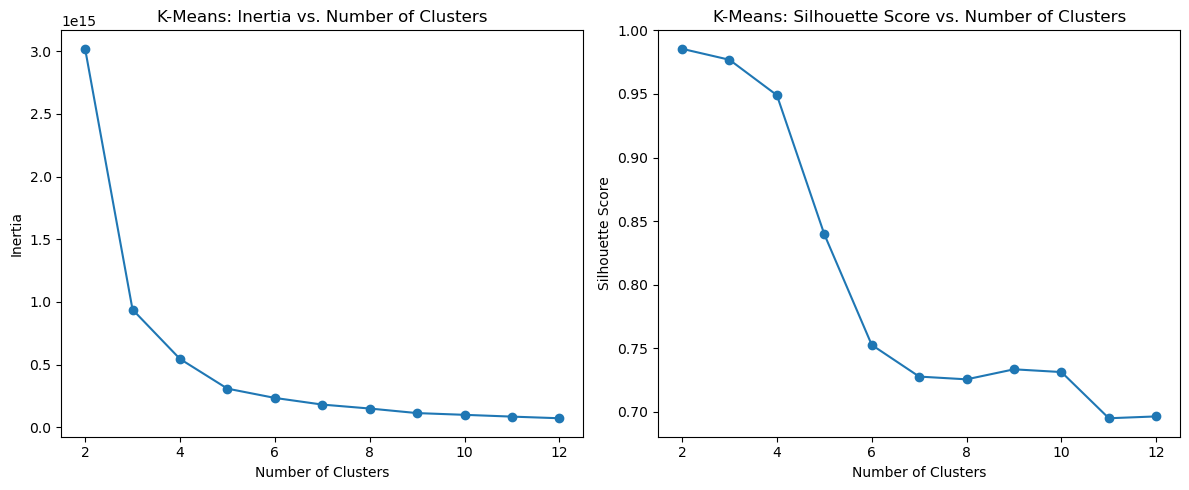

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_clusters, inertia_errors, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("K-Means: Inertia vs. Number of Clusters")

plt.subplot(1, 2, 2)
plt.plot(n_clusters, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means: Silhouette Score vs. Number of Clusters")
plt.tight_layout()
plt.show()

The inertia plot shows a distinct "elbow" at `k=4`, while the silhouette score is also high at this point. This provides strong evidence that four clusters is the optimal number for this model. We then built and visualized the final model with `k=4`.

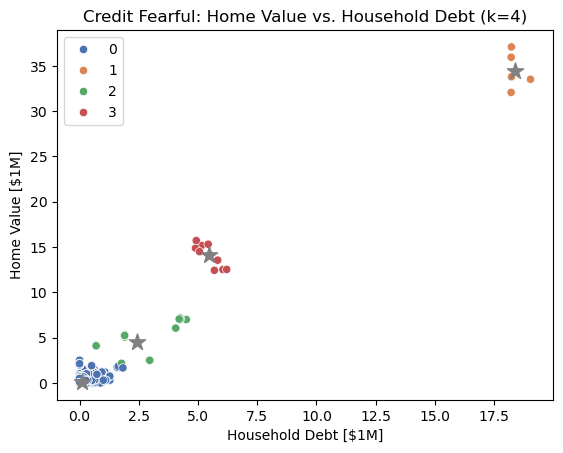

In [10]:
final_model_2_features = KMeans(n_clusters=4, random_state=42, n_init=10)
final_model_2_features.fit(X)
labels = final_model_2_features.labels_
centroids = final_model_2_features.cluster_centers_

sns.scatterplot(
    x=(df_fear["DEBT"] / 1e6),
    y=(df_fear["HOUSES"] / 1e6),
    hue=labels,
    palette="deep"
)
plt.scatter(
    x=centroids[:, 0] / 1e6,
    y=centroids[:, 1] / 1e6,
    color="gray",
    marker="*",
    s=150,
    label="Centroids"
)
plt.xlabel("Household Debt [$1M]")
plt.ylabel("Home Value [$1M]")
plt.title("Credit Fearful: Home Value vs. Household Debt (k=4)");

### Phase 2: Multi-Feature Clustering with Preprocessing

To create more nuanced segments, we expanded our model to include more features. A key challenge in high-dimensional clustering is feature selection and scaling.

**Feature Selection:** We chose features with the highest variance, as they contribute most to the differentiation between data points. However, standard variance can be skewed by extreme outliers common in financial data. We therefore used **trimmed variance**, which excludes the top and bottom 10% of values for a more robust measure.

**Data Preprocessing:** The selected features (`NETWORTH`, `ASSET`, `DEBT`, `HOUSES`, `LIQ`) operate on vastly different scales. To prevent features with larger magnitudes from dominating the clustering process, we used `StandardScaler` to transform each feature to have a mean of 0 and a standard deviation of 1. This entire process was encapsulated in a scikit-learn `Pipeline`.

In [11]:
# Wrangle function to also remove high-net-worth outliers for this more detailed model
def wrangle_multi_feature(filepath):
    df = pd.read_csv(filepath)
    mask = (df["TURNFEAR"] == 1) & (df['NETWORTH'] < 2e6)
    return df[mask]

df_multi = wrangle_multi_feature("data/SCFP2019.csv.gz")

top_five_trim_var = df_multi.apply(trimmed_var).sort_values().tail(5)
high_var_cols = top_five_trim_var.index.to_list()
X_multi = df_multi[high_var_cols]

n_clusters_multi = range(2, 13)
inertia_errors_multi = []
silhouette_scores_multi = []

for k in n_clusters_multi:
    model = make_pipeline(
        StandardScaler(), 
        KMeans(n_clusters=k, random_state=42, n_init=10)
    )
    model.fit(X_multi)
    inertia_errors_multi.append(model.named_steps['kmeans'].inertia_)
    silhouette_scores_multi.append(silhouette_score(X_multi, model.named_steps['kmeans'].labels_))


Again, we evaluated the optimal `k`, and `k=4` emerged as the strongest choice. The challenge then became visualizing these 5-dimensional clusters. We employed **Principal Component Analysis (PCA)**, a dimensionality reduction technique, to project the 5-dimensional data down to two principal components (`PC1` and `PC2`) that capture the maximum possible variance.

In [12]:
final_model_multi = make_pipeline(
    StandardScaler(), 
    KMeans(n_clusters=4, random_state=42, n_init=10)
)
final_model_multi.fit(X_multi)
labels_multi = final_model_multi.named_steps['kmeans'].labels_

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_multi)
X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
X_pca_df["labels"] = labels_multi.astype(str)

fig = px.scatter(
    data_frame=X_pca_df,
    x='PC1',
    y='PC2',
    color='labels',
    title="PCA Representation of 5-Feature Clusters"
)
fig.show()

## 4. Key Findings and Business Implications

The multi-feature clustering model provides a rich, nuanced view of our target households. By examining the mean financial indicators for each of the four clusters, we can construct actionable customer personas.

In [13]:
xgb = X_multi.groupby(labels_multi).mean()

fig = px.bar(
    xgb,
    barmode="group",
    title="Mean Household Finances by Cluster"
)
fig.update_layout(xaxis_title="Cluster", yaxis_title="Value [$]")
fig.show()

### Customer Personas & Recommendations

- **Cluster 0: The Under-Leveraged.** This group has very low debt relative to their assets and home value. While they have moderate net worth, they are not effectively using leverage. 
  - **Recommendation:** Target with home equity lines of credit (HELOCs), investment-backed loans, and financial advisory services to help them utilize their assets more effectively.

- **Cluster 1: The House-Rich, Asset-Poor.** This segment's net worth is almost entirely tied up in their primary residence. Their debt levels are significant, closely tracking their home's value, and they hold few liquid assets.
  - **Recommendation:** Offer mortgage refinancing to lower their monthly payments, debt consolidation products, and information about building an emergency fund.

- **Cluster 2: The Aspiring Affluent.** This group has the highest net worth and assets in our sample, along with substantial home value. Their debt levels are also high, suggesting they are comfortable using credit to finance a more expensive lifestyle or investments.
  - **Recommendation:** This is a prime market for premium credit cards, wealth management services, and specialized loan products for investments or luxury purchases.

- **Cluster 3: The Financially Strained.** This group has the lowest net worth, assets, and home value, yet still carries a moderate amount of debt. This is the most financially vulnerable segment.
  - **Recommendation:** Focus on financial literacy resources, secured credit cards to help rebuild credit, and low-cost banking solutions.


## 5. Interactive Dashboard for Stakeholder Engagement

To make these findings accessible and empower ongoing exploration, we developed an interactive dashboard using Plotly Dash. This tool allows non-technical stakeholders to:

1.  Select between trimmed and non-trimmed variance for feature selection.
2.  Adjust the number of clusters (`k`) with a simple slider.
3.  Instantly see how these changes affect the model's performance metrics (Inertia and Silhouette Score).
4.  Visualize the resulting clusters in the PCA scatter plot.

This dashboard transforms a static report into a dynamic analytical tool, fostering data-driven conversations and strategy development. The complete code for the application is provided below.

In [14]:
# 1. Application Instantiation
app = Dash(__name__)

# 2. Data Wrangling Function
def wrangle(filepath):
    df = pd.read_csv(filepath)
    mask = (df["TURNFEAR"] == 1) & (df['NETWORTH'] < 2e6)
    return df[mask]

df = wrangle("data/SCFP2019.csv.gz")

# 3. Helper Functions
def get_high_var_features(trimmed=True, return_feat_names=True):
    if trimmed:
        top_five_features = df.apply(trimmed_var).sort_values().tail(5)
    else:
        top_five_features = df.var().sort_values().tail(5)
    
    if return_feat_names:
        top_five_features = top_five_features.index.to_list()
    return top_five_features

def get_model_metrics(trimmed=True, k=2, return_metrics=False):
    features = get_high_var_features(trimmed=trimmed, return_feat_names=True)
    X = df[features]
    model = make_pipeline(StandardScaler(), KMeans(n_clusters=k, random_state=42, n_init=10))
    model.fit(X)
    
    if return_metrics:
        inertia = model.named_steps['kmeans'].inertia_
        silhouette = silhouette_score(X, model.named_steps['kmeans'].labels_)
        metrics = {"Inertia": round(inertia), "Silhouette Score": round(silhouette, 3)}
        return metrics
    return model

def get_pca_labels(trimmed=True, k=2):
    features = get_high_var_features(trimmed=trimmed, return_feat_names=True)
    X = df[features]
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    X_pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
    model = get_model_metrics(trimmed=trimmed, k=k, return_metrics=False)
    X_pca_df["labels"] = model.named_steps['kmeans'].labels_.astype(str)
    X_pca_df.sort_values("labels", inplace=True)
    return X_pca_df

# 4. Application Layout
app.layout = html.Div([
    html.H1("Survey of Consumer Finances: Customer Segmentation"),
    html.H2("High Variance Features"),
    dcc.RadioItems(
        id="trim-button",
        options=[
            {"label": "Trimmed Variance", "value": True},
            {"label": "Standard Variance", "value": False}
        ],
        value=True
    ),
    dcc.Graph(id='bar-chart'),
    html.H2("K-Means Clustering"),
    html.H3("Number of Clusters (k)"),
    dcc.Slider(
        id='k-slider',
        min=2, max=12, step=1, value=4,
        marks={i: str(i) for i in range(2, 13)}
    ),
    html.Div(id="metrics"),
    dcc.Graph(id='pca-scatter')
])

# 5. Callbacks
@app.callback(
    Output("bar-chart", 'figure'),
    Input("trim-button", 'value'),
)
def serve_bar_chart(trimmed=True):
    top_five_features = get_high_var_features(trimmed=trimmed, return_feat_names=False)
    fig = px.bar(x=top_five_features, y=top_five_features.index, orientation="h")
    fig.update_layout(xaxis_title="Variance", yaxis_title="Features", title="Top 5 High-Variance Features")
    return fig

@app.callback(
    Output('metrics', 'children'),
    Input('trim-button', 'value'),
    Input('k-slider', 'value')
)
def serve_metrics(trimmed=True, k=2):
    metrics = get_model_metrics(trimmed=trimmed, k=k, return_metrics=True)
    text = [
        html.H3(f"Inertia: {metrics['Inertia']}"),
        html.H3(f"Silhouette Score: {metrics['Silhouette Score']}")
    ]
    return text

@app.callback(
    Output("pca-scatter", 'figure'),
    Input("trim-button", 'value'),
    Input("k-slider", 'value'),
)
def serve_scatter_plot(trimmed=True, k=2):
    X_pca_df = get_pca_labels(trimmed=trimmed, k=k)
    fig = px.scatter(
        data_frame=X_pca_df,
        x="PC1", y="PC2", color="labels",
        title="PCA Representation of Clusters"
    )
    fig.update_layout(xaxis_title='Principal Component 1', yaxis_title="Principal Component 2")
    return fig

# 6. Application Deployment (for local execution)
# To run the app, you would execute the following line in your environment:
if __name__ == '__main__':
    app.run(debug=True, host="0.0.0.0", port=8050)

## 6. Conclusion and Next Steps

This project successfully demonstrated the power of unsupervised learning to derive meaningful customer segments from complex financial data. We have moved from raw data to actionable business intelligence, creating four distinct customer personas from the pool of credit-anxious households. The strategies recommended for each persona are designed to improve customer engagement, increase product uptake, and reduce financial risk.

**Future work could involve:**
- **Enriching Personas:** Incorporating more demographic and behavioral data to build even more detailed profiles of each segment.
- **Predictive Modeling:** Building a classification model to predict which segment a new customer is most likely to belong to, allowing for proactive and personalized outreach.
- **A/B Testing:** Implementing the recommended strategies and using A/B testing to measure their impact on key business metrics like conversion rates and customer satisfaction.

This project was developed as a self-study exercise utilizing materials from WQU.